In [1]:
import sys

sys.path.append("../..")

In [2]:
from xaikd import models, datasets
from xaikd.utils import metrics

import pandas as pd 

from matplotlib import pyplot as plt 

In [3]:
ds = datasets.construct("cifar10")
dl = ds.loader(train_split=False)

In [4]:
def ano():
    rows = []
    for model_name in [
        "cifar10-resnet18-simclr_finetuned_fc1",
        "cifar10-resnet18-simclr_finetuned_all1",
        "cifar10-resnet18-p1",

    ]:
        model = models.get_model(model_name)
        acc = metrics.accuracy(model, dl, num_classes=10, device="cpu")
        print(f"[{model_name}]: {acc}")

        rows.append(dict(model=model_name, acc=acc))
        
    return pd.DataFrame(rows)

df = ano()

Downloading: "https://tubcloud.tu-berlin.de/s/bwrNFY36KSy7KYj/download/resnet18simclr-finetune-fc-cifar10-seed1.pth" to /home/pat/.cache/torch/hub/checkpoints/resnet18simclr-finetune-fc-cifar10-seed1.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42.7M/42.7M [00:05<00:00, 8.81MB/s]


[cifar10-resnet18-simclr_finetuned_fc1]: 0.7908999919891357
[cifar10-resnet18-simclr_finetuned_all1]: 0.8962000012397766
[cifar10-resnet18-p1]: 0.9189000129699707


Text(0, 0.5, 'Accuracy')

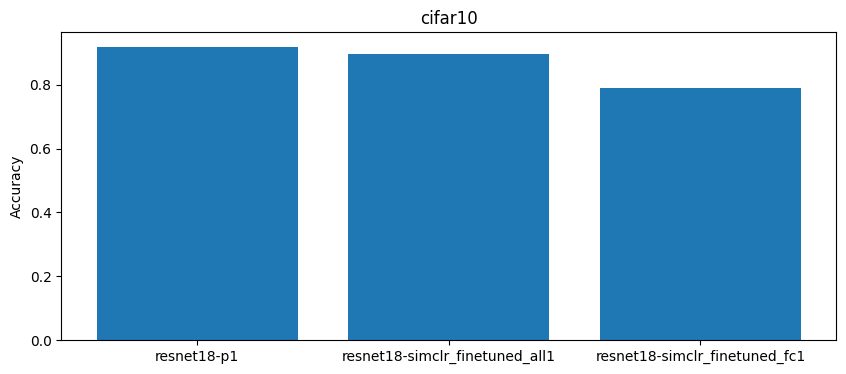

In [10]:
plt.figure(figsize=(10, 4))
df = df.sort_values(by="model")
plt.title("cifar10")
plt.bar(
    list(map(lambda x: x.replace("cifar10-", ""), df.model)),
    df.acc
)
plt.ylabel("Accuracy")